# Boo Who? · Phase 1: Data Cleaning

This notebook checks the monster data, fixes what is wrong, and prepares clean files for the model (Phase 2) and the game (Phase 4).

**Inputs** (in `../data/`): `monster_train.csv`, `monster_comp.csv`, `sample_sub.csv`
**Outputs** (in `../data/clean/` and `../reports/`): cleaned and scaled data, preprocessing settings for the game, figures and a cleaning report.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('../data'); CLEAN = DATA / 'clean'; REPORTS = Path('../reports'); FIGS = REPORTS / 'figures'
for p in (CLEAN, FIGS): p.mkdir(parents=True, exist_ok=True)

NUM = ['height', 'rottingFleshPct', 'bloodCoverage', 'aura', 'hairLength']
COLORS = ['green', 'grey', 'purple', 'white']
CLASSES = ['Zombie', 'Witch', 'Ghost', 'Vampire', 'Mummy']      # fixed order, largest to smallest
# one fixed colour per class, used in every chart (validated categorical palette, slots 1-5)
CLASS_COLOR = dict(zip(CLASSES, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']))

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#8a8984', 'axes.labelcolor': '#52514e', 'xtick.color': '#52514e',
                     'ytick.color': '#52514e', 'axes.titleweight': 'bold', 'axes.titlesize': 11})
log = []   # every cleaning decision, collected for the report

## 1. Load the data

In [2]:
train = pd.read_csv(DATA / 'monster_train.csv')
comp  = pd.read_csv(DATA / 'monster_comp.csv')
sub   = pd.read_csv(DATA / 'sample_sub.csv')
print('train:', train.shape, '| comp:', comp.shape, '| sample_sub:', sub.shape)
train.head()

train: (37497, 8) | comp: (12503, 7) | sample_sub: (12503, 2)


,id,class,height,color,rottingFleshPct,bloodCoverage,aura,hairLength
0,1,Zombie,61.624796,green,24.37,25.009,0.153880,3.331372
1,2,Ghost,51.408600,white,3.52,7.211,0.210933,3.314029
2,3,Witch,61.419138,purple,22.78,19.478,0.174245,3.481500
3,4,Zombie,52.970681,green,29.82,23.499,0.169031,3.335083
4,5,Witch,57.270176,purple,27.25,13.082,0.215114,3.041551


In [3]:
train.dtypes

id                   int64
class                  str
height             float64
color                  str
rottingFleshPct    float64
bloodCoverage      float64
aura               float64
hairLength         float64
dtype: object

## 2. Missing values, duplicates and ids

In [4]:
print('Missing values (train):', int(train.isna().sum().sum()), '| (comp):', int(comp.isna().sum().sum()))
print('Duplicate ids (train):', int(train.id.duplicated().sum()), '| (comp):', int(comp.id.duplicated().sum()))
print('Duplicate monsters, same features (train):', int(train.duplicated(subset=NUM + ['color']).sum()))
print('Ids shared by train and comp:', len(set(train.id) & set(comp.id)))
print('comp ids match sample_sub ids:', comp.id.equals(sub.id))

Missing values (train): 0 | (comp): 0
Duplicate ids (train): 0 | (comp): 0
Duplicate monsters, same features (train): 0
Ids shared by train and comp: 12503
comp ids match sample_sub ids: True


There are no missing values and no duplicates. **Important:** the ids in train and comp overlap (both start at 1), so an id does not identify a monster across files. We never join the two files on `id`, and `id` is never used as a feature.

In [5]:
log.append('No missing values or duplicate rows in either file.')
log.append('Train and comp ids overlap (both start at 1): files are kept separate and id is not a feature.')

## 3. Class balance

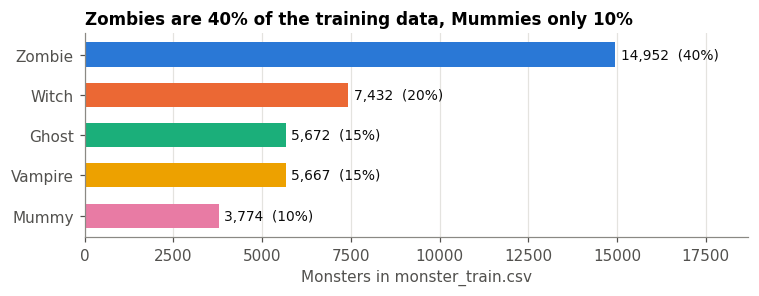

In [6]:
counts = train['class'].value_counts().reindex(CLASSES)
fig, ax = plt.subplots(figsize=(7, 2.8))
bars = ax.barh(CLASSES[::-1], counts[::-1], color=[CLASS_COLOR[c] for c in CLASSES[::-1]], height=0.6)
for b, c in zip(bars, CLASSES[::-1]):
    ax.text(b.get_width() + 150, b.get_y() + b.get_height() / 2, f"{counts[c]:,}  ({counts[c] / len(train):.0%})",
            va='center', color='#0b0b0b', fontsize=9)
ax.set_title('Zombies are 40% of the training data, Mummies only 10%', loc='left')
ax.set_xlabel('Monsters in monster_train.csv'); ax.set_xlim(0, counts.max() * 1.25)
ax.xaxis.grid(True, color='#e4e3df'); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGS / 'class_balance.png', bbox_inches='tight'); plt.show()

The classes are imbalanced (Zombie has 4 times as many rows as Mummy). We keep all rows, and in Phase 2 we use **stratified splits** and **macro-F1** so the small classes count fairly.

In [7]:
log.append('Classes are imbalanced (Zombie 40%, Mummy 10%): no resampling now; Phase 2 uses stratified splits, macro-F1 and class weights.')

## 4. Categories in `color`

In [8]:
for name, df in [('train', train), ('comp', comp)]:
    print(name, sorted(df.color.unique()))
train['color'] = train.color.str.strip().str.lower(); comp['color'] = comp.color.str.strip().str.lower()
assert set(train.color) == set(comp.color) == set(COLORS)

train ['green', 'grey', 'purple', 'white']
comp ['green', 'grey', 'purple', 'white']


The four colors are already clean and identical in both files. Color is also a strong clue:

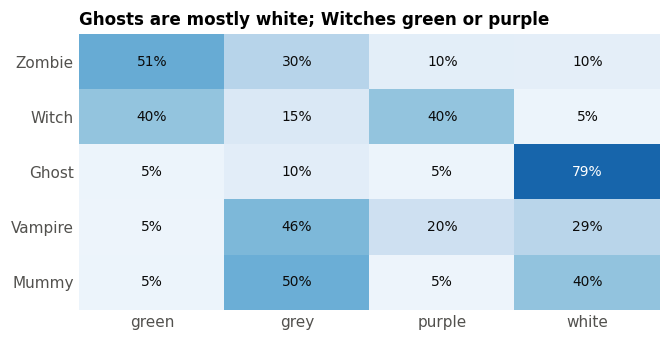

color,green,grey,purple,white
class,,,,
Zombie,50.8,29.6,10.0,9.6
Witch,40.1,14.5,40.2,5.2
Ghost,5.2,10.3,5.1,79.4
Vampire,4.8,45.6,20.4,29.2
Mummy,5.3,49.6,4.7,40.4


In [9]:
share = pd.crosstab(train['class'], train.color, normalize='index').reindex(CLASSES)[COLORS] * 100
fig, ax = plt.subplots(figsize=(6.2, 3.2))
im = ax.imshow(share.values, cmap='Blues', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(4), COLORS); ax.set_yticks(range(5), CLASSES)
for i in range(5):
    for j in range(4):
        v = share.values[i, j]
        ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=9, color='white' if v > 55 else '#0b0b0b')
ax.set_title('Ghosts are mostly white; Witches green or purple', loc='left')
ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]
plt.tight_layout(); plt.savefig(FIGS / 'color_by_class.png', bbox_inches='tight'); plt.show()
share.round(1)

In [10]:
log.append('color has exactly 4 clean values (green, grey, purple, white) in both files; strong clue (79% of Ghosts are white).')

## 5. Ranges and invalid values

In [11]:
pd.concat({'train': train[NUM].describe().T[['min', 'mean', 'max']], 'comp': comp[NUM].describe().T[['min', 'mean', 'max']]}, axis=1).round(3)

train                    comp                
                    min    mean     max     min    mean     max
height           22.125  60.480  83.070  30.186  60.468  83.322
rottingFleshPct   1.530  20.979  48.770   3.040  20.990  46.610
bloodCoverage    -2.634  19.281  58.864   0.001  19.345  59.504
aura              0.020   0.197   0.540   0.035   0.196   0.496
hairLength        1.943   3.469   5.388   2.029   3.466   5.160

In [12]:
bad = train[(train.bloodCoverage < 0) | (train.bloodCoverage > 100) | (train.rottingFleshPct < 0) | (train.rottingFleshPct > 100)]
bad

,id,class,height,color,rottingFleshPct,bloodCoverage,aura,hairLength
34962,34963,Zombie,62.894144,green,30.17,-2.634,0.142234,3.926731


`rottingFleshPct` and `bloodCoverage` are percentages, so they must be between 0 and 100. One training Zombie has a **negative blood coverage (-2.634)**, which is impossible. It is most likely a measurement error close to zero, so we clip it to 0 instead of deleting the monster.

In [13]:
n_bad = len(bad)
for col in ['rottingFleshPct', 'bloodCoverage']:
    train[col] = train[col].clip(0, 100); comp[col] = comp[col].clip(0, 100)
log.append(f'Clipped percentages to 0-100: {n_bad} train row changed (bloodCoverage -2.634 set to 0). Comp had none.')

## 6. Outliers

In [14]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return (s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)

out = pd.DataFrame({
    'IQR rule, whole data': [int(iqr_outliers(train[c]).sum()) for c in NUM],
    'IQR rule, within each class': [int(train.groupby('class')[c].transform(iqr_outliers).sum()) for c in NUM],
    'More than 4 std from mean': [int(((train[c] - train[c].mean()).abs() > 4 * train[c].std()).sum()) for c in NUM],
}, index=NUM)
out

,"IQR rule, whole data","IQR rule, within each class",More than 4 std from mean
height,629,149,8
rottingFleshPct,0,373,0
bloodCoverage,0,104,0
aura,96,263,1
hairLength,229,229,2


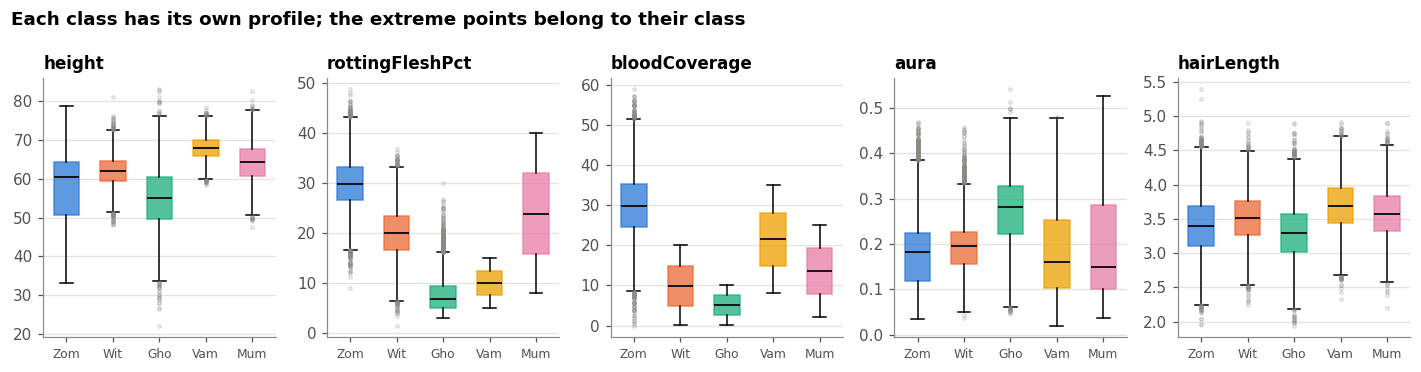

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3.4), sharey=False)
for ax, col in zip(axes, NUM):
    data = [train.loc[train['class'] == c, col] for c in CLASSES]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, flierprops=dict(marker='o', markersize=2, alpha=0.3, markeredgecolor='#8a8984'),
                    medianprops=dict(color='#0b0b0b', linewidth=1.2))
    for patch, c in zip(bp['boxes'], CLASSES):
        patch.set_facecolor(CLASS_COLOR[c]); patch.set_alpha(0.75); patch.set_edgecolor(CLASS_COLOR[c])
    ax.set_title(col, loc='left'); ax.set_xticks(range(1, 6), [c[:3] for c in CLASSES], fontsize=8)
    ax.yaxis.grid(True, color='#e4e3df'); ax.set_axisbelow(True)
fig.suptitle('Each class has its own profile; the extreme points belong to their class', x=0.01, ha='left', fontweight='bold')
plt.tight_layout(); plt.savefig(FIGS / 'features_by_class.png', bbox_inches='tight'); plt.show()

In [16]:
train.nsmallest(5, 'height')[['id', 'class', 'height', 'color', 'aura']]

,id,class,height,color,aura
16119,16120,Ghost,22.124607,white,0.289639
5595,5596,Ghost,26.264609,white,0.382344
18263,18264,Ghost,26.661380,white,0.307545
36132,36133,Ghost,27.809224,grey,0.115291
15232,15233,Ghost,27.898098,white,0.296336


**Decision: keep the outliers.** Most "outliers" on the whole data are simply the natural tails of one class, for example the shortest monsters (22 to 28) are all Ghosts, and Ghosts are the shortest class. Removing them would delete real signal. Only 11 values in the whole training set are more than 4 standard deviations from the mean, and none of them are impossible values. Tree models are not affected by outliers, and the scaler below is only used for the linear model.

For the game, the model inputs are later limited to the range seen in training, so a monster can never have values the model has never seen.

In [17]:
log.append('Outliers kept: extreme values are natural tails of a class (e.g. shortest monsters are all Ghosts); only 11 values are beyond 4 std and none are impossible.')

## 7. Train and comp look alike

In [18]:
cmp = pd.DataFrame({'train mean': train[NUM].mean(), 'comp mean': comp[NUM].mean(),
                    'train std': train[NUM].std(), 'comp std': comp[NUM].std()}).round(3)
cmp['mean diff (in std)'] = ((cmp['comp mean'] - cmp['train mean']) / cmp['train std']).round(3)
cmp

,train mean,comp mean,train std,comp std,mean diff (in std)
height,60.480,60.468,7.756,7.782,-0.002
rottingFleshPct,20.979,20.990,10.223,10.243,0.001
bloodCoverage,19.281,19.345,12.005,12.073,0.005
aura,0.197,0.196,0.085,0.085,-0.012
hairLength,3.469,3.466,0.419,0.416,-0.007


In [19]:
color_share = pd.DataFrame({'train': train.color.value_counts(normalize=True), 'comp': comp.color.value_counts(normalize=True)}).round(3)
color_share

,train,comp
color,,
green,0.303,0.298
grey,0.281,0.286
white,0.253,0.253
purple,0.163,0.163


In [20]:
log.append('Train and comp have the same distributions (all mean differences under 0.02 std): a model trained on train should work on comp.')

## 8. Feature relationships

In [21]:
train[NUM].corr().round(2)

,height,rottingFleshPct,bloodCoverage,aura,hairLength
height,1.00,-0.12,-0.01,-0.10,0.56
rottingFleshPct,-0.12,1.00,0.51,-0.21,-0.06
bloodCoverage,-0.01,0.51,1.00,-0.21,0.00
aura,-0.10,-0.21,-0.21,1.00,-0.06
hairLength,0.56,-0.06,0.00,-0.06,1.00


`rottingFleshPct` and `bloodCoverage` go together (0.51), and so do `height` and `hairLength` (0.56). No pair is so strong that one feature is a copy of another, so all five are kept.

In [22]:
log.append('No feature is redundant (highest correlation 0.56, height vs hairLength): all 5 numeric features kept.')

## 9. Encode and scale

In [23]:
def encode(df):
    out = df.copy()
    for c in COLORS:
        out[f'color_{c}'] = (out.color == c).astype(int)
    return out.drop(columns='color')

train_clean = encode(train)
comp_clean = encode(comp)
FEATURES = NUM + [f'color_{c}' for c in COLORS]

# scaler fit on TRAIN only, then applied to both files (no information leaks from comp)
mean = train_clean[NUM].mean(); std = train_clean[NUM].std(ddof=0)
train_scaled = train_clean.copy(); comp_scaled = comp_clean.copy()
train_scaled[NUM] = (train_clean[NUM] - mean) / std
comp_scaled[NUM] = (comp_clean[NUM] - mean) / std
train_scaled[NUM].describe().round(2).loc[['mean', 'std']]

,height,rottingFleshPct,bloodCoverage,aura,hairLength
mean,0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0


In [24]:
log.append('color one-hot encoded into 4 columns (color_green, color_grey, color_purple, color_white).')
log.append('Numeric features standardised with mean and std from train only, then applied to comp.')

## 10. Save the outputs

In [25]:
train_clean.to_csv(CLEAN / 'train_clean.csv', index=False)
comp_clean.to_csv(CLEAN / 'comp_clean.csv', index=False)
train_scaled.to_csv(CLEAN / 'train_scaled.csv', index=False)
comp_scaled.to_csv(CLEAN / 'comp_scaled.csv', index=False)

# settings the web game needs to prepare a monster exactly like Python does
prep = {
    'features': FEATURES, 'numeric': NUM, 'colors': COLORS, 'classes': CLASSES,
    'scaler': {c: {'mean': round(float(mean[c]), 6), 'std': round(float(std[c]), 6)} for c in NUM},
    'train_range': {c: {'min': round(float(train[c].min()), 6), 'max': round(float(train[c].max()), 6)} for c in NUM},
    'class_means': train.groupby('class')[NUM].mean().round(3).reindex(CLASSES).to_dict(orient='index'),
}
(CLEAN / 'preprocessing.json').write_text(json.dumps(prep, indent=2))

report = ['# Boo Who? · Phase 1 cleaning report', '',
          f'- Training monsters: {len(train):,} (all kept)', f'- Competition monsters: {len(comp):,} (all kept)',
          f'- Features for the model: {len(FEATURES)} ({", ".join(FEATURES)})', '', '## Decisions', '']
report += [f'{i}. {x}' for i, x in enumerate(log, 1)]
report += ['', '## Files created', '', '- data/clean/train_clean.csv and comp_clean.csv: cleaned, color one-hot, original units',
           '- data/clean/train_scaled.csv and comp_scaled.csv: same, numeric features standardised',
           '- data/clean/preprocessing.json: scaler, ranges, class means (used by the game)',
           '- reports/figures/: class_balance.png, color_by_class.png, features_by_class.png']
(REPORTS / 'cleaning_report.md').write_text('\n'.join(report))
print('\n'.join(report))

# Boo Who? · Phase 1 cleaning report

- Training monsters: 37,497 (all kept)
- Competition monsters: 12,503 (all kept)
- Features for the model: 9 (height, rottingFleshPct, bloodCoverage, aura, hairLength, color_green, color_grey, color_purple, color_white)

## Decisions

1. No missing values or duplicate rows in either file.
2. Train and comp ids overlap (both start at 1): files are kept separate and id is not a feature.
3. Classes are imbalanced (Zombie 40%, Mummy 10%): no resampling now; Phase 2 uses stratified splits, macro-F1 and class weights.
4. color has exactly 4 clean values (green, grey, purple, white) in both files; strong clue (79% of Ghosts are white).
5. Clipped percentages to 0-100: 1 train row changed (bloodCoverage -2.634 set to 0). Comp had none.
6. Outliers kept: extreme values are natural tails of a class (e.g. shortest monsters are all Ghosts); only 11 values are beyond 4 std and none are impossible.
7. Train and comp have the same distributions (all mean differen

## Summary

The data was already in good shape. One impossible value was fixed, outliers were kept on purpose, color was encoded and the numbers were scaled. **Next: Phase 2, training and comparing classifiers.**